In [3]:
import pandas as pd
import pandas_gbq
import numpy as np
import itertools
import datetime
import matplotlib.pyplot as plt
from datetime import datetime
from datetime import *
from datetime import datetime, timedelta, date
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)  # Show full column width


# Standard plotly imports
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [5]:
#Change the date to the previous day
query = """
SELECT
A.GAME_ID, GAME_DATE, MATCHUP, EVENTNUM, PERIOD, PCTIMESTRING, EVENTMSGTYPE, EVENTMSGACTIONTYPE,
CASE WHEN EVENTMSGTYPE=1 THEN 'Made FG'
     WHEN EVENTMSGTYPE=2 THEN 'Missed FG'
     WHEN EVENTMSGTYPE=3 THEN 'Free Throw Attempts'
     WHEN EVENTMSGTYPE=4 THEN 'Rebound'
     WHEN EVENTMSGTYPE=5 THEN 'Turnover'
     WHEN EVENTMSGTYPE=6 THEN 'Foul'
     WHEN EVENTMSGTYPE=7 THEN 'Violation'
     WHEN EVENTMSGTYPE=8 THEN 'Substitution'
     WHEN EVENTMSGTYPE=9 THEN 'Timeout'
     WHEN EVENTMSGTYPE=10 THEN 'Jump Ball'
     WHEN EVENTMSGTYPE=11 THEN 'Ejection'
     WHEN EVENTMSGTYPE=12 THEN 'Period Begin'
     WHEN EVENTMSGTYPE=13 THEN 'Period End'
     END as Event,
CASE WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=0 THEN 'No Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=1 THEN 'Jump Shot/3PT Jump Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=2 THEN 'RUNNING JUMP SHOT/ 3PT RUNNING JUMP SHOT'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=3 THEN 'Hook Shot/3PT Hook Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=4 THEN 'Tip Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=5 THEN 'Layup/3PT Layup'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=6 THEN 'Driving Layup'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=7 THEN 'Dunk'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=8 THEN 'Slam Dunk'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=9 THEN 'Driving Dunk'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=40 THEN '3PT Layup'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=41 THEN 'Running Layup'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=42 THEN 'Driving Layup'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=43 THEN 'Alley-oop Layup'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=44 THEN 'Reverse Layup/3PT Reverse Layup'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=46 THEN 'Running Jump Shot/3PT Running Jump Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=47 THEN 'Turnaround Jump Shot/3PT Turnaround Jump Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=49 THEN 'Driving Dunk'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=50 THEN 'Running Dunk'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=51 THEN 'Reverse Dunk'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=52 THEN 'Alley-oop Dunk'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=54 THEN 'Running Tip Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=56 THEN 'Running Hook Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=57 THEN 'Driving Hook Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=58 THEN 'Turnaround Hook Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=59 THEN 'Finger Roll/3PT Finger Roll'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=60 THEN 'Running Finger Roll'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=61 THEN 'Driving Finger Roll'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=62 THEN 'Turnaround Finger Roll'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=63 THEN 'Fadeaway Jumper/3PT Fadeaway Jumper'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=64 THEN 'Follow up Dunk'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=65 THEN 'Jump Hook Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=66 THEN 'Jump Bank Shot/3PT Jump Bank Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=67 THEN 'Hook Bank Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=71 THEN 'Finger Roll Layup'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=72 THEN 'Putback Layup/3PT Putback Layup'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=73 THEN 'Driving Reverse Layup'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=74 THEN 'Running Reverse Layup'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=75 THEN 'Driving Finger Roll Layup'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=76 THEN 'Running Finger Roll Layup'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=77 THEN 'Driving Jump Shot/3PT Driving Jump Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=78 THEN 'Floating Jump Shot/3PT Floating Jump Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=79 THEN 'Pullup Jump Shot/3PT Pullup Jump Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=80 THEN 'Step Back Jump Shot/3PT Step Back Jump Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=81 THEN 'Pullup Bank Shot/3PT Pullup Bank Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=82 THEN 'Driving Bank Shot/3PT Driving Bank Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=83 THEN 'Fadeaway Bank Shot/3PT Fadeaway Bank Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=84 THEN 'Running Bank Shot/3PT Running Bank Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=85 THEN 'Turnaround Bank Shot/3PT Turnaround Bank Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=86 THEN 'Turnaround Fadeaway/3PT Turnaround Fadeaway'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=87 THEN 'Putback Dunk'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=88 THEN 'Driving Slam Dunk'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=89 THEN 'Reverse Slam Dunk'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=90 THEN 'Running Slam Dunk'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=91 THEN 'Putback Reverse Dunk'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=92 THEN 'Putback Slam Dunk'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=93 THEN 'Driving Bank Hook Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=94 THEN 'Jump Bank Hook Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=95 THEN 'Running Bank Hook Shot/3PT Running Bank Hook Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=96 THEN 'Turnaround Bank Hook Shot/3PT Turnaround Bank Hook Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=97 THEN 'Tip Layup Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=98 THEN 'Cutting Layup Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=99 THEN 'Cutting Finger Roll Layup Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=100 THEN 'Running Alley-oop Layup Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=101 THEN 'Driving Floating Jump Shot/3PT Driving Floating Jump Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=102 THEN 'Driving Floating Bank Jump Shot/3PT Driving Floating Bank Jump Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=103 THEN 'Running Pull/3PT Running Pull'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=104 THEN 'Step Back Bank Jump Shot/3PT Step Back Bank Jump Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=105 THEN 'Turnaround Fadeaway Bank Jump Shot/3PT Turnaround Fadeaway Bank Jump Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=106 THEN 'Running Alley-oop Dunk Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=107 THEN 'Tip Dunk Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=108 THEN 'Cutting Dunk Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=109 THEN 'Driving Reverse Dunk Shot'
     WHEN EVENTMSGTYPE IN (1,2) AND EVENTMSGACTIONTYPE=110 THEN 'Running Reverse Dunk Shot'
     WHEN EVENTMSGTYPE IN (3) AND EVENTMSGACTIONTYPE=10 THEN 'Free Throw 1 of 1'
     WHEN EVENTMSGTYPE IN (3) AND EVENTMSGACTIONTYPE=11 THEN 'Free Throw 1 of 2'
     WHEN EVENTMSGTYPE IN (3) AND EVENTMSGACTIONTYPE=12 THEN 'Free Throw 2 of 2'
     WHEN EVENTMSGTYPE IN (3) AND EVENTMSGACTIONTYPE=13 THEN 'Free Throw 1 of 3'
     WHEN EVENTMSGTYPE IN (3) AND EVENTMSGACTIONTYPE=14 THEN 'Free Throw 2 of 3'
     WHEN EVENTMSGTYPE IN (3) AND EVENTMSGACTIONTYPE=15 THEN 'Free Throw 3 of 3'
     WHEN EVENTMSGTYPE IN (3) AND EVENTMSGACTIONTYPE=16 THEN 'Free Throw Technical 1 of 1'
     WHEN EVENTMSGTYPE IN (3) AND EVENTMSGACTIONTYPE=18 THEN 'Free Throw Flagrant 1 of 2'
     WHEN EVENTMSGTYPE IN (3) AND EVENTMSGACTIONTYPE=19 THEN 'Free Throw Flagrant 2 of 2'
     WHEN EVENTMSGTYPE IN (3) AND EVENTMSGACTIONTYPE=20 THEN 'Free Throw Flagrant 1 of 1'
     WHEN EVENTMSGTYPE IN (3) AND EVENTMSGACTIONTYPE=21 THEN 'Free Throw Technical 1 of 2'
     WHEN EVENTMSGTYPE IN (3) AND EVENTMSGACTIONTYPE=22 THEN 'Free Throw Technical 2 of 2'
     WHEN EVENTMSGTYPE IN (3) AND EVENTMSGACTIONTYPE=25 THEN 'Free Throw Clear Path 1 of 2'
     WHEN EVENTMSGTYPE IN (3) AND EVENTMSGACTIONTYPE=26 THEN 'Free Throw Clear Path 2 of 2'
     WHEN EVENTMSGTYPE IN (3) AND EVENTMSGACTIONTYPE=27 THEN 'Free Throw Flagrant 1 of 3'
     WHEN EVENTMSGTYPE IN (3) AND EVENTMSGACTIONTYPE=28 THEN 'Free Throw Flagrant 2 of 3'
     WHEN EVENTMSGTYPE IN (3) AND EVENTMSGACTIONTYPE=29 THEN 'Free Throw Flagrant 3 of 3'
     WHEN EVENTMSGTYPE IN (4) THEN 'Rebound'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=0 THEN 'Flagrant Foul: No Turnover'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=1 THEN 'Bad Pass TO: Steal'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=2 THEN 'Lost Ball TO: Steal'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=4 THEN 'Traveling TO'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=6 THEN 'Double Dribble TO'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=7 THEN 'Discontinue Dribble TO'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=8 THEN '3 Second Violation TO'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=9 THEN '5 Second Violation TO'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=10 THEN '8 Second Violation TO'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=11 THEN 'Shot Clock TO'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=12 THEN 'Inbound TO'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=13 THEN 'Backcourt TO'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=14 THEN 'Illegal pick TO'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=15 THEN 'Offensive Goaltending TO'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=16 THEN 'Isolation Violation TO'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=17 THEN 'Lane Violation TO'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=18 THEN 'Jump Ball Violation TO'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=19 THEN 'Kicked Ball Violation TO '
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=20 THEN 'Illegal Assist TO'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=21 THEN 'Palming TO'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=22 THEN 'Post up TO'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=23 THEN 'Double personal TO'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=32 THEN 'Opposite basket TO'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=33 THEN 'Punched ball TO'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=34 THEN 'Swinging elbows TO'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=35 THEN 'Basket from below TO'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=36 THEN 'Illegal Screen'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=37 THEN 'Offensive Foul TO'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=38 THEN '5 second inbound TO'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=39 THEN 'Step out of bounds TO'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=40 THEN 'Out of bounds lost ball TO'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=41 THEN 'Poss lost ball TO'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=42 THEN 'Excess Timeout TO'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=43 THEN 'Player OOB TO'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=44 THEN 'Too many players TO'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=45 THEN 'Out of bounds bad pass TO'
     WHEN EVENTMSGTYPE IN (5) AND EVENTMSGACTIONTYPE=52 THEN 'STL TO'
     WHEN EVENTMSGTYPE IN (6) AND EVENTMSGACTIONTYPE=1 THEN 'Personal Foul'
     WHEN EVENTMSGTYPE IN (6) AND EVENTMSGACTIONTYPE=2 THEN 'S Foul'
     WHEN EVENTMSGTYPE IN (6) AND EVENTMSGACTIONTYPE=3 THEN 'L.B. Foul'
     WHEN EVENTMSGTYPE IN (6) AND EVENTMSGACTIONTYPE=4 THEN 'Offensive Foul'
     WHEN EVENTMSGTYPE IN (6) AND EVENTMSGACTIONTYPE=5 THEN 'In. Foul'
     WHEN EVENTMSGTYPE IN (6) AND EVENTMSGACTIONTYPE=6 THEN 'Away from play foul'
     WHEN EVENTMSGTYPE IN (6) AND EVENTMSGACTIONTYPE=7 THEN 'Elbow Foul'
     WHEN EVENTMSGTYPE IN (6) AND EVENTMSGACTIONTYPE=8 THEN 'Punch Foul'
     WHEN EVENTMSGTYPE IN (6) AND EVENTMSGACTIONTYPE=9 THEN 'C.P. Foul'
     WHEN EVENTMSGTYPE IN (6) AND EVENTMSGACTIONTYPE=10 THEN 'Double personal Foul'
     WHEN EVENTMSGTYPE IN (6) AND EVENTMSGACTIONTYPE=11 THEN 'T. Foul'
     WHEN EVENTMSGTYPE IN (6) AND EVENTMSGACTIONTYPE=12 THEN 'Non-Unsportsmanlike Foul'
     WHEN EVENTMSGTYPE IN (6) AND EVENTMSGACTIONTYPE=13 THEN 'Hanging Tech Foul'
     WHEN EVENTMSGTYPE IN (6) AND EVENTMSGACTIONTYPE=14 THEN 'Flagrant Foul Type 1'
     WHEN EVENTMSGTYPE IN (6) AND EVENTMSGACTIONTYPE=15 THEN 'Flagrant Foul Type 2'
     WHEN EVENTMSGTYPE IN (6) AND EVENTMSGACTIONTYPE=16 THEN 'Double Technical'
     WHEN EVENTMSGTYPE IN (6) AND EVENTMSGACTIONTYPE=17 THEN 'Team T. Foul'
     WHEN EVENTMSGTYPE IN (6) AND EVENTMSGACTIONTYPE=18 THEN 'Team Delay Technical'
     WHEN EVENTMSGTYPE IN (6) AND EVENTMSGACTIONTYPE=19 THEN 'Taunting '
     WHEN EVENTMSGTYPE IN (6) AND EVENTMSGACTIONTYPE=25 THEN 'Excess Timeout Technical'
     WHEN EVENTMSGTYPE IN (6) AND EVENTMSGACTIONTYPE=26 THEN 'Offensive Charge Foul'
     WHEN EVENTMSGTYPE IN (6) AND EVENTMSGACTIONTYPE=27 THEN 'Personal Block Foul'
     WHEN EVENTMSGTYPE IN (6) AND EVENTMSGACTIONTYPE=28 THEN 'Personal Take Foul'
     WHEN EVENTMSGTYPE IN (6) AND EVENTMSGACTIONTYPE=29 THEN 'Shooting Block Foul'
     WHEN EVENTMSGTYPE IN (6) AND EVENTMSGACTIONTYPE=30 THEN 'Too many Players Foul'
     WHEN EVENTMSGTYPE IN (7) AND EVENTMSGACTIONTYPE=0 THEN 'Violation: No violation'
     WHEN EVENTMSGTYPE IN (7) AND EVENTMSGACTIONTYPE=1 THEN 'Violation: Delay of game '
     WHEN EVENTMSGTYPE IN (7) AND EVENTMSGACTIONTYPE=2 THEN 'Defensive Goaltending'
     WHEN EVENTMSGTYPE IN (7) AND EVENTMSGACTIONTYPE=3 THEN 'Lane Violation'
     WHEN EVENTMSGTYPE IN (7) AND EVENTMSGACTIONTYPE=4 THEN 'Jump Ball Violation'
     WHEN EVENTMSGTYPE IN (7) AND EVENTMSGACTIONTYPE=5 THEN 'Kicked Ball Violation'
     WHEN EVENTMSGTYPE IN (7) AND EVENTMSGACTIONTYPE=6 THEN 'Double Lane Violation'
     WHEN EVENTMSGTYPE IN (8)  THEN 'Substitution'
     WHEN EVENTMSGTYPE IN (9) AND EVENTMSGACTIONTYPE=0 THEN 'Timeout: No Timeout'
     WHEN EVENTMSGTYPE IN (9) AND EVENTMSGACTIONTYPE=1 THEN 'Timeout Regular'
     WHEN EVENTMSGTYPE IN (9) AND EVENTMSGACTIONTYPE=2 THEN 'Timeout Short'
     WHEN EVENTMSGTYPE IN (9) AND EVENTMSGACTIONTYPE=3 THEN 'Timeout official TV'
     WHEN EVENTMSGTYPE IN (9) AND EVENTMSGACTIONTYPE=4 THEN 'Timeout Official'
     WHEN EVENTMSGTYPE IN (9) AND EVENTMSGACTIONTYPE=5 THEN 'Timeout Advance'
     WHEN EVENTMSGTYPE IN (9) AND EVENTMSGACTIONTYPE=7 THEN 'Coach Challenge'
     WHEN EVENTMSGTYPE IN (10) AND EVENTMSGACTIONTYPE=0 THEN 'Jump ball'
     WHEN EVENTMSGTYPE IN (10) AND EVENTMSGACTIONTYPE=1 THEN 'Jump ball CC'
     WHEN EVENTMSGTYPE IN (11) AND EVENTMSGACTIONTYPE=0 THEN 'Ejection: No ejection'
     WHEN EVENTMSGTYPE IN (11) AND EVENTMSGACTIONTYPE=1 THEN 'Ejection: Second Technical'
     WHEN EVENTMSGTYPE IN (11) AND EVENTMSGACTIONTYPE=2 THEN 'Ejection: Second Flagrant Type 1 '
     WHEN EVENTMSGTYPE IN (11) AND EVENTMSGACTIONTYPE=3 THEN 'Ejection: First Flagrant Type 2'
     WHEN EVENTMSGTYPE IN (11) AND EVENTMSGACTIONTYPE=4 THEN 'Ejection: Other'
     WHEN EVENTMSGTYPE IN (12) THEN 'Start of period'
     WHEN EVENTMSGTYPE IN (13) THEN 'End of period'
     ELSE 'No event'
     END as Event_Type,

HOMEDESCRIPTION, NEUTRALDESCRIPTION, VISITORDESCRIPTION, SCORE, SCOREMARGIN, PERSON1TYPE, PLAYER1_ID, PLAYER1_NAME, PLAYER1_TEAM_ID, PLAYER1_TEAM_CITY, PLAYER1_TEAM_NICKNAME, PLAYER1_TEAM_ABBREVIATION, PERSON2TYPE, PLAYER2_ID, PLAYER2_NAME, PLAYER2_TEAM_ID, PLAYER2_TEAM_CITY, PLAYER2_TEAM_NICKNAME, PLAYER2_TEAM_ABBREVIATION, PERSON3TYPE, PLAYER3_ID, PLAYER3_NAME, PLAYER3_TEAM_ID, PLAYER3_TEAM_CITY, PLAYER3_TEAM_NICKNAME, PLAYER3_TEAM_ABBREVIATION, VIDEO_AVAILABLE_FLAG, WCTIMESTRING, A.Season
FROM
`perceptive-ivy-290216.play_by_play.reg_season_97_98` A
INNER JOIN
nba_game_player_team_ids.game_ids_reg_season B
ON A.GAME_ID =B.GAME_ID
WHERE A.GAME_ID IN ('0029700672')
AND MATCHUP LIKE '%@%'
ORDER BY 4"""
project_id = "perceptive-ivy-290216"
df_bq = pandas_gbq.read_gbq(query, project_id=project_id, dialect='standard')

Downloading: 100%|██████████|


In [6]:
query2 = """
SELECT TEAM_ABBREVIATION, GAME_ID, GAME_DATE, WL, FGM, FGA, FG_PCT, FG3M, FG3A, FG3_PCT, FTM, FTA, FT_PCT, OREB, DREB, REB, AST, STL, BLK, TOV, PF, PTS FROM `perceptive-ivy-290216.nba_api_team_boxscore.team_box_96_onwards`
WHERE TEAM_ABBREVIATION="CHI"
AND SEASON='1997-98'
AND MATCHUP LIKE "%CHI @%"
"""
project_id = "perceptive-ivy-290216"
result_bq = pandas_gbq.read_gbq(query2, project_id=project_id, dialect='standard')
result_bq.head()

Downloading: 100%|██████████|


,TEAM_ABBREVIATION,GAME_ID,GAME_DATE,WL,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS
0,CHI,0029700525,1998-01-15,L,38,83,0.458,3,10,0.300,17,24,0.708,20,31,51,24,8,4,21,29,96
1,CHI,0029701154,1998-04-15,L,34,84,0.405,4,16,0.250,7,15,0.467,16,27,43,22,9,3,14,17,79
2,CHI,0029700084,1997-11-11,L,31,84,0.369,1,7,0.143,17,22,0.773,19,27,46,22,7,0,19,19,80
3,CHI,0029700198,1997-11-28,L,34,83,0.410,0,6,0.000,15,28,0.536,11,28,39,17,7,4,6,22,83
4,CHI,0029700280,1997-12-10,L,36,80,0.450,4,14,0.286,22,27,0.815,15,25,40,27,6,3,15,23,98


In [7]:
#Change the date to the previous day
query_shooting = """
SELECT
GAME_ID as GAME, PLAYER_NAME, PERIOD PERIOD_LOC, MINUTES_REMAINING, SECONDS_REMAINING, SHOT_TYPE, SHOT_ZONE_BASIC
FROM `perceptive-ivy-290216.nba_api_shooting_location.x_y_location`
WHERE SEASON='1997-98'
# AND GAME_ID='0041500407'
ORDER BY PERIOD, MINUTES_REMAINING DESC, SECONDS_REMAINING DESC
"""
project_id = "perceptive-ivy-290216"
shooting_df = pandas_gbq.read_gbq(query_shooting, project_id=project_id, dialect='standard')
shooting_df.head()

Downloading: 100%|██████████|


,GAME,PLAYER_NAME,PERIOD_LOC,MINUTES_REMAINING,SECONDS_REMAINING,SHOT_TYPE,SHOT_ZONE_BASIC
0,0029700002,Kendall Gill,1,11,59,2PT Field Goal,Restricted Area
1,0029700165,Reggie Miller,1,11,58,2PT Field Goal,Restricted Area
2,0029700577,Brent Barry,1,11,58,3PT Field Goal,Above the Break 3
3,0029700873,Reggie Miller,1,11,58,2PT Field Goal,Restricted Area
4,0029701032,Michael Finley,1,11,57,2PT Field Goal,Restricted Area


In [8]:
game=df_bq
game=game.replace("TIE",'0')
game["RK"] = game.groupby("GAME_ID")["EVENTNUM"].rank(method="dense", ascending=True)
game = game.sort_values(['GAME_ID','EVENTNUM']).reset_index(drop=True)

In [9]:
#Make the first row of each game id as 0 for score and score margin, otherwise the next game inherits the prior game's score and scoremargin in the next steps due to no delineation
for index, row in game.iterrows():
  if game.loc[index, 'RK']==1.0:
    game.loc[index, 'SCOREMARGIN']=0
    game.loc[index, 'SCORE']='0-0'

In [10]:

game['SCOREMARGIN'] = game['SCOREMARGIN'].fillna(method='ffill')
game['SCORE'] = game['SCORE'].fillna(method='ffill')
game=game.fillna('No')
game['SCOREMARGIN']=game['SCOREMARGIN'].astype(int)

/var/folders/x_/b65sxrpx6737wtqnt0ctv71w0000gn/T/ipykernel_30948/973979870.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  game['SCOREMARGIN'] = game['SCOREMARGIN'].fillna(method='ffill')
/var/folders/x_/b65sxrpx6737wtqnt0ctv71w0000gn/T/ipykernel_30948/973979870.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  game['SCORE'] = game['SCORE'].fillna(method='ffill')


In [11]:

game[['MINUTE', 'SECOND']] = game['PCTIMESTRING'].str.split(':',n=1, expand=True)
game["MINUTE"]=game["MINUTE"].astype(int)
game["SECOND"]=game["SECOND"].astype(int)
game["SECONDS"]=game["MINUTE"]*60+game["SECOND"]

In [12]:
game.sort_values(['GAME_ID', 'PERIOD', 'SECONDS'], ascending=[True, True, False], inplace=True)
game['overall_rank'] = 1
game['overall_rank'] = game.groupby(['GAME_ID'])['overall_rank'].cumsum()
game.head()

,GAME_ID,GAME_DATE,MATCHUP,EVENTNUM,PERIOD,PCTIMESTRING,EVENTMSGTYPE,EVENTMSGACTIONTYPE,Event,Event_Type,HOMEDESCRIPTION,NEUTRALDESCRIPTION,VISITORDESCRIPTION,SCORE,SCOREMARGIN,PERSON1TYPE,PLAYER1_ID,PLAYER1_NAME,PLAYER1_TEAM_ID,PLAYER1_TEAM_CITY,PLAYER1_TEAM_NICKNAME,PLAYER1_TEAM_ABBREVIATION,PERSON2TYPE,PLAYER2_ID,PLAYER2_NAME,PLAYER2_TEAM_ID,PLAYER2_TEAM_CITY,PLAYER2_TEAM_NICKNAME,PLAYER2_TEAM_ABBREVIATION,PERSON3TYPE,PLAYER3_ID,PLAYER3_NAME,PLAYER3_TEAM_ID,PLAYER3_TEAM_CITY,PLAYER3_TEAM_NICKNAME,PLAYER3_TEAM_ABBREVIATION,VIDEO_AVAILABLE_FLAG,WCTIMESTRING,Season,RK,MINUTE,SECOND,SECONDS,overall_rank
0,0029700672,1998-02-04,CHI @ UTA,0,1,12:00,12,0,Period Begin,Start of period,No,Start of 1st Period (11:13 AM EST),No,0-0,0,0,0,No,No,No,No,No,0,0,No,No,No,No,No,0,0,No,No,No,No,No,0,11:13 AM,1997-98,1.0,12,0,720,1
1,0029700672,1998-02-04,CHI @ UTA,1,1,12:00,10,0,Jump Ball,Jump ball,Jump Ball Ostertag vs. Longley: Tip to Jordan,No,No,0-0,0,4,731,Greg Ostertag,1610612762.0,Utah,Jazz,UTA,5,26,Luc Longley,1610612741.0,Chicago,Bulls,CHI,5,893,Michael Jordan,1610612741.0,Chicago,Bulls,CHI,0,12:05 PM,1997-98,2.0,12,0,720,2
2,0029700672,1998-02-04,CHI @ UTA,2,1,11:39,2,1,Missed FG,Jump Shot/3PT Jump Shot,No,No,MISS Longley 19' Jump Shot,0-0,0,5,26,Luc Longley,1610612741.0,Chicago,Bulls,CHI,0,0,No,No,No,No,No,0,0,No,No,No,No,No,0,12:06 PM,1997-98,3.0,11,39,699,3
3,0029700672,1998-02-04,CHI @ UTA,3,1,11:36,4,0,Rebound,Rebound,No,No,Rodman REBOUND (Off:1 Def:0),0-0,0,5,23,Dennis Rodman,1610612741.0,Chicago,Bulls,CHI,0,0,No,No,No,No,No,0,0,No,No,No,No,No,0,12:06 PM,1997-98,4.0,11,36,696,4
4,0029700672,1998-02-04,CHI @ UTA,4,1,11:27,6,2,Foul,S Foul,Ostertag S.FOUL (P1.T1),No,No,0-0,0,4,731,Greg Ostertag,1610612762.0,Utah,Jazz,UTA,0,0,No,No,No,No,No,0,0,No,No,No,No,No,0,12:06 PM,1997-98,5.0,11,27,687,5


In [13]:
# game_edited=pd.concat([game,game[['SECONDS']].shift(periods=-1).rename({'SECONDS':'SECONDS_SHIFTED'}, axis=1)], axis=1)
game_edited=pd.concat([game,game[['SECONDS']].diff().rename({'SECONDS':'SECONDS_Diff'}, axis=1)], axis=1)
game_edited=pd.concat([game_edited,game_edited[['SCOREMARGIN']].diff().rename({'SCOREMARGIN':'SCOREMARGIN_Diff'}, axis=1)], axis=1)
game_edited["SECONDS_Diff"]=game_edited["SECONDS_Diff"].abs()
game_edited["SCOREMARGIN_Diff"]=game_edited["SCOREMARGIN_Diff"].abs()
game_edited.tail()

,GAME_ID,GAME_DATE,MATCHUP,EVENTNUM,PERIOD,PCTIMESTRING,EVENTMSGTYPE,EVENTMSGACTIONTYPE,Event,Event_Type,HOMEDESCRIPTION,NEUTRALDESCRIPTION,VISITORDESCRIPTION,SCORE,SCOREMARGIN,PERSON1TYPE,PLAYER1_ID,PLAYER1_NAME,PLAYER1_TEAM_ID,PLAYER1_TEAM_CITY,PLAYER1_TEAM_NICKNAME,PLAYER1_TEAM_ABBREVIATION,PERSON2TYPE,PLAYER2_ID,PLAYER2_NAME,PLAYER2_TEAM_ID,PLAYER2_TEAM_CITY,PLAYER2_TEAM_NICKNAME,PLAYER2_TEAM_ABBREVIATION,PERSON3TYPE,PLAYER3_ID,PLAYER3_NAME,PLAYER3_TEAM_ID,PLAYER3_TEAM_CITY,PLAYER3_TEAM_NICKNAME,PLAYER3_TEAM_ABBREVIATION,VIDEO_AVAILABLE_FLAG,WCTIMESTRING,Season,RK,MINUTE,SECOND,SECONDS,overall_rank,SECONDS_Diff,SCOREMARGIN_Diff
418,0029700672,1998-02-04,CHI @ UTA,447,4,0:17,1,7,Made FG,Dunk,No,No,Jordan Dunk (40 PTS),93 - 99,6,5,893,Michael Jordan,1610612741.0,Chicago,Bulls,CHI,0,0,No,No,No,No,No,0,0,No,No,No,No,No,0,2:18 PM,1997-98,419.0,0,17,17,419,3.0,2.0
419,0029700672,1998-02-04,CHI @ UTA,448,4,0:08,1,8,Made FG,Slam Dunk,Carr Slam Dunk (4 PTS) (Malone 4 AST),No,No,93 - 101,8,4,156,Antoine Carr,1610612762.0,Utah,Jazz,UTA,4,252,Karl Malone,1610612762.0,Utah,Jazz,UTA,0,0,No,No,No,No,No,0,2:19 PM,1997-98,420.0,0,8,8,420,9.0,2.0
420,0029700672,1998-02-04,CHI @ UTA,449,4,0:03,2,1,Missed FG,Jump Shot/3PT Jump Shot,No,No,MISS Burrell 27' 3PT Jump Shot,93 - 101,8,5,197,Scott Burrell,1610612741.0,Chicago,Bulls,CHI,0,0,No,No,No,No,No,0,0,No,No,No,No,No,0,2:19 PM,1997-98,421.0,0,3,3,421,5.0,0.0
421,0029700672,1998-02-04,CHI @ UTA,451,4,0:00,4,0,Rebound,Rebound,Carr REBOUND (Off:0 Def:3),No,No,93 - 101,8,4,156,Antoine Carr,1610612762.0,Utah,Jazz,UTA,0,0,No,No,No,No,No,0,0,No,No,No,No,No,0,2:19 PM,1997-98,422.0,0,0,0,422,3.0,0.0
422,0029700672,1998-02-04,CHI @ UTA,452,4,0:00,13,0,Period End,End of period,No,End of 4th Period (2:19 PM EST),No,93 - 101,8,0,0,No,No,No,No,No,0,0,No,No,No,No,No,0,0,No,No,No,No,No,0,2:19 PM,1997-98,423.0,0,0,0,423,0.0,0.0


In [14]:
BLOCK_ALL_GAMES=game_edited
BLOCK_ALL_GAMES=BLOCK_ALL_GAMES[BLOCK_ALL_GAMES["Event_Type"]!="Start of period"]
BLOCK_ALL_GAMES=BLOCK_ALL_GAMES.sort_values(by=["GAME_ID","PERIOD","SECONDS"], ascending=[True, True, False])

In [15]:
#Add a column to check scoremargin and if it is =/>/< than 0
for index,row in BLOCK_ALL_GAMES.iterrows():
  if row['SCOREMARGIN']==0:
    BLOCK_ALL_GAMES.loc[index,'LEAD_LAG'] = 'ALL'
  elif row['SCOREMARGIN']>0:
    BLOCK_ALL_GAMES.loc[index,'LEAD_LAG'] = 'HOME LEAD'
  elif row['SCOREMARGIN']<0:
    BLOCK_ALL_GAMES.loc[index,'LEAD_LAG'] = 'HOME DEFICIT'

In [16]:
#Add a column to check scoremargin and if it is =/>/< than 0
for index,row in BLOCK_ALL_GAMES.iterrows():
  if ((row['SECONDS']<=720) & (row['SECONDS']>300)):
    BLOCK_ALL_GAMES.loc[index,'CLUTCH'] = '6-12 MIN'
  elif ((row['SECONDS']<=300) & (row['SECONDS']>120)):
    BLOCK_ALL_GAMES.loc[index,'CLUTCH'] = '2-5 MIN'
  elif ((row['SECONDS']<=120)):
    BLOCK_ALL_GAMES.loc[index,'CLUTCH'] = 'LESS THAN 2 MIN'
  # elif ((row['SECONDS']<=120) & (row['SECONDS']>60)):
  #   BLOCK_ALL_GAMES.loc[index,'CLUTCH'] = '1-2 MIN'
  # elif ((row['SECONDS']<=60) & (row['SECONDS']>30)):
  #   BLOCK_ALL_GAMES.loc[index,'CLUTCH'] = '30 SEC-1 MIN'
  # elif ((row['SECONDS']<=30)):
  #   BLOCK_ALL_GAMES.loc[index,'CLUTCH'] = 'LESS THAN 30 SEC'

In [17]:
#Add a column to check scoremargin and if it is =/>/< than 0
for index,row in BLOCK_ALL_GAMES.iterrows():
  if row['SCOREMARGIN']==0:
    BLOCK_ALL_GAMES.loc[index,'MARGIN'] = '0'
  elif ((row['SCOREMARGIN']<=5) & (row['SCOREMARGIN']>0)):
    BLOCK_ALL_GAMES.loc[index,'MARGIN'] = '<=5'
  elif ((row['SCOREMARGIN']<=10) & (row['SCOREMARGIN']>5)):
    BLOCK_ALL_GAMES.loc[index,'MARGIN'] = '6-10'
  elif ((row['SCOREMARGIN']<=20) & (row['SCOREMARGIN']>10)):
    BLOCK_ALL_GAMES.loc[index,'MARGIN'] = '11-20'
  elif ((row['SCOREMARGIN']>20)):
    BLOCK_ALL_GAMES.loc[index,'MARGIN'] = '>20'

  elif ((row['SCOREMARGIN']>=-5) & (row['SCOREMARGIN']<0)):
    BLOCK_ALL_GAMES.loc[index,'MARGIN'] = '<=5'
  elif ((row['SCOREMARGIN']>=-10) & (row['SCOREMARGIN']<-5)):
    BLOCK_ALL_GAMES.loc[index,'MARGIN'] = '6-10'
  elif ((row['SCOREMARGIN']>=-20) & (row['SCOREMARGIN']<-10)):
    BLOCK_ALL_GAMES.loc[index,'MARGIN'] = '11-20'
  elif ((row['SCOREMARGIN']<-20)):
    BLOCK_ALL_GAMES.loc[index,'MARGIN'] = '>20'

In [18]:
# BLOCK_ALL_GAMES=BLOCK_ALL_GAMES.merge(result_bq, how='left', left_on=['GAME_ID','GAME_DATE'], right_on=['GAME_ID','GAME_DATE'])
# BLOCK_ALL_GAMES=BLOCK_ALL_GAMES.merge(shooting_df, how='left', left_on=['GAME_ID','MINUTE','SECOND','PLAYER1_NAME','PERIOD'], right_on=['GAME','MINUTES_REMAINING','SECONDS_REMAINING','PLAYER_NAME','PERIOD_LOC'])

In [77]:
test=BLOCK_ALL_GAMES

#Create another column with the lag(1) value to compare
test["SM2"]=test["SCOREMARGIN"].shift(1)
test=test.fillna(0)
test["SM2"]=test["SM2"].astype(int)

for index,row in test.iterrows():
  if row['RK']==2.0:
    test.loc[index,'SM2'] =0

#Create another column to track lead changes in the game
for i in test.GAME_ID.unique():
  for index,row in test.iterrows():
    if row.GAME_ID==i:
    #multiply current and previous row.If the value is -ve, it means the sign has flipped and one of them is -ve. This is how we track a lead change
      if row['SCOREMARGIN']*row['SM2']<0:
        test.loc[index,'WAYPOINT'] = "Lead Switch"
      elif (row['SCOREMARGIN']*row['SM2']==0) & ((row['SCOREMARGIN']!=0) | (row['SM2']!=0)):
        test.loc[index,'WAYPOINT'] = "Lead Switch"  
      else:
        test.loc[index,'WAYPOINT'] = "No Change"  

#Create a counter to track phases of the game
#This for condition is to account for each game and reset the counter after each game
for i in test.GAME_ID.unique():
    num=1
    for index,row in test.iterrows():
        if row.GAME_ID==i:
            if ((row['Event']=='Jump Ball')&(row['EVENTNUM']==1)):
                test.loc[index,'PHASE']=0
            if row['WAYPOINT']=='Lead Switch':
                test.loc[index,'PHASE']=num
                num=num+1
test["PHASE"] = test["PHASE"].ffill()
test=test.fillna(0)
test["PHASE"]=test["PHASE"].astype(int)
test=test.drop('SM2',axis=1)                

# Create a conversion value of +1 or -1 which can then be applied to the max score difference. Doing this 
# So that we can directly calculate the max score difference in each phase and then apply the conversion factor.
# As calculating the max/min in each phase diff might not be easy 

for index,row in test.iterrows():
  if row['SCOREMARGIN']<0:
    test.loc[index,'PHASE CONV']= -1
  elif row['SCOREMARGIN']>0:
    test.loc[index,'PHASE CONV'] = 1
  elif row['SCOREMARGIN']==0:
    test.loc[index,'PHASE CONV'] = 0

#Get max score diff in each phase, then apply PHASE CONV to ensure that lead/lag is accounted for
test["SCORE MARGIN ABS"]=test["SCOREMARGIN"].abs()
test["PHASE DIFFERENTIAL ABS"]=test.groupby(["GAME_ID","PHASE"])["SCORE MARGIN ABS"].transform('max')
test["PHASE DIFFERENTIAL HOME"]=test["PHASE DIFFERENTIAL ABS"]*test["PHASE CONV"]
test["PHASE DIFFERENTIAL ROAD"]=test["PHASE DIFFERENTIAL HOME"]*(-1)
test=test.drop(['PHASE CONV','SCORE MARGIN ABS','PHASE DIFFERENTIAL ABS'],axis=1)   
test["PHASE DIFFERENTIAL HOME"]=test["PHASE DIFFERENTIAL HOME"].astype(int)
test["PHASE DIFFERENTIAL ROAD"]=test["PHASE DIFFERENTIAL ROAD"].astype(int)


#Create a df to store all game phases
all_df2=pd.DataFrame(test.groupby(["GAME_ID","PHASE"])[["PHASE DIFFERENTIAL HOME","PHASE DIFFERENTIAL ROAD"]].max(['unique']))
all_df2=all_df2.reset_index()
all_df2.columns=["GAME_ID", "PHASE", "ALL PHASES HOME","ALL PHASES ROAD"]
home_df=pd.DataFrame(all_df2.groupby(["GAME_ID"])["ALL PHASES HOME"].apply(list))
road_df=pd.DataFrame(all_df2.groupby(["GAME_ID"])["ALL PHASES ROAD"].apply(list))

home_df=home_df.reset_index(level=[0])
road_df=road_df.reset_index(level=[0])
final_df=home_df.merge(road_df, how='left', left_on="GAME_ID", right_on="GAME_ID")

#Join this df with the original df
test=test.merge(final_df, how='left', left_on="GAME_ID", right_on="GAME_ID")

In [106]:
all_df2=pd.DataFrame(test.groupby(["EVENTNUM","GAME_ID","PHASE"])[["PHASE DIFFERENTIAL HOME","PHASE DIFFERENTIAL ROAD"]].max(['unique']))
# all_df2=all_df2.reset_index()
all_df2

,,,PHASE DIFFERENTIAL HOME,PHASE DIFFERENTIAL ROAD
EVENTNUM,GAME_ID,PHASE,,
1,0029700672,0,0,0
2,0029700672,0,0,0
3,0029700672,0,0,0
4,0029700672,0,0,0
5,0029700672,1,-2,2
6,0029700672,1,-2,2
7,0029700672,1,-2,2
8,0029700672,1,-2,2
9,0029700672,1,-2,2


In [76]:
# test[['EVENTNUM','SCORE','SCOREMARGIN', 'SM2','SCOREMARGIN_Diff','LEAD_LAG', 'WAYPOINT','PHASE']]

In [78]:
#Create a new df which has the previous value of phase differential for the home and road teams. I'm unable to figure out a way other than creating a new df and then joining it to the actual df
df_with_phase_values=pd.DataFrame(test.groupby(["GAME_ID","PHASE"])[["PHASE DIFFERENTIAL HOME","PHASE DIFFERENTIAL ROAD"]].max(['unique']))
df_with_phase_values=df_with_phase_values.reset_index()
df_with_phase_values[['PHASE DIFFERENTIAL HOME']]=df_with_phase_values[['PHASE DIFFERENTIAL HOME']].shift(1)
df_with_phase_values[['PHASE DIFFERENTIAL ROAD']]=df_with_phase_values[['PHASE DIFFERENTIAL ROAD']].shift(1)
df_with_phase_values=df_with_phase_values.fillna(0)
df_with_phase_values.columns=['GAME_ID2','PHASE_2','PHASE DIFFERENTIAL HOME PRIOR','PHASE DIFFERENTIAL ROAD PRIOR']

#Join this new table that has the previous values of home and road differential for points
test=test.merge(df_with_phase_values, how='left', left_on=["GAME_ID","PHASE"], right_on=["GAME_ID2","PHASE_2"])

#This calculates the previous phase that existed for the teams. Then we can get the delta between the current and prior phase
test['PHASE DELTA HOME']=test['PHASE DIFFERENTIAL HOME']-test['PHASE DIFFERENTIAL HOME PRIOR']
test['PHASE DELTA ROAD']=test['PHASE DIFFERENTIAL ROAD']-test['PHASE DIFFERENTIAL ROAD PRIOR']

# test=test.drop(['GAME_ID2','PHASE_2','PHASE DIFFERENTIAL HOME PRIOR','PHASE DIFFERENTIAL ROAD PRIOR'],axis=1)  

test=test[['GAME_ID','GAME_DATE', 'MATCHUP', 'EVENTNUM', 'PERIOD', 'PCTIMESTRING', 'Event', 'Event_Type','HOMEDESCRIPTION',
       'NEUTRALDESCRIPTION', 'VISITORDESCRIPTION', 'SCORE','SCOREMARGIN', 'PLAYER1_NAME', 'PLAYER1_TEAM_ABBREVIATION','PLAYER2_NAME', 
       'PLAYER2_TEAM_ABBREVIATION', 'PLAYER3_NAME', 'PLAYER3_TEAM_ABBREVIATION', 'Season',
       'RK','SCOREMARGIN_Diff','LEAD_LAG', 'CLUTCH', 'MARGIN', 'WAYPOINT', 'PHASE','PHASE DIFFERENTIAL HOME',
       'PHASE DELTA HOME','PHASE DIFFERENTIAL ROAD','PHASE DELTA ROAD', 'ALL PHASES HOME','ALL PHASES ROAD']]

test.head(5)

,GAME_ID,GAME_DATE,MATCHUP,EVENTNUM,PERIOD,PCTIMESTRING,Event,Event_Type,HOMEDESCRIPTION,NEUTRALDESCRIPTION,VISITORDESCRIPTION,SCORE,SCOREMARGIN,PLAYER1_NAME,PLAYER1_TEAM_ABBREVIATION,PLAYER2_NAME,PLAYER2_TEAM_ABBREVIATION,PLAYER3_NAME,PLAYER3_TEAM_ABBREVIATION,Season,RK,SCOREMARGIN_Diff,LEAD_LAG,CLUTCH,MARGIN,WAYPOINT,PHASE,PHASE DIFFERENTIAL HOME,PHASE DELTA HOME,PHASE DIFFERENTIAL ROAD,PHASE DELTA ROAD,ALL PHASES HOME,ALL PHASES ROAD
0,0029700672,1998-02-04,CHI @ UTA,1,1,12:00,Jump Ball,Jump ball,Jump Ball Ostertag vs. Longley: Tip to Jordan,No,No,0-0,0,Greg Ostertag,UTA,Luc Longley,CHI,Michael Jordan,CHI,1997-98,2.0,0.0,ALL,6-12 MIN,0,No Change,0,0,0.0,0,0.0,"[0, -2, 0, -24, 0, 1, -7, 2, 0, 2, -1, 8]","[0, 2, 0, 24, 0, -1, 7, -2, 0, -2, 1, -8]"
1,0029700672,1998-02-04,CHI @ UTA,2,1,11:39,Missed FG,Jump Shot/3PT Jump Shot,No,No,MISS Longley 19' Jump Shot,0-0,0,Luc Longley,CHI,No,No,No,No,1997-98,3.0,0.0,ALL,6-12 MIN,0,No Change,0,0,0.0,0,0.0,"[0, -2, 0, -24, 0, 1, -7, 2, 0, 2, -1, 8]","[0, 2, 0, 24, 0, -1, 7, -2, 0, -2, 1, -8]"
2,0029700672,1998-02-04,CHI @ UTA,3,1,11:36,Rebound,Rebound,No,No,Rodman REBOUND (Off:1 Def:0),0-0,0,Dennis Rodman,CHI,No,No,No,No,1997-98,4.0,0.0,ALL,6-12 MIN,0,No Change,0,0,0.0,0,0.0,"[0, -2, 0, -24, 0, 1, -7, 2, 0, 2, -1, 8]","[0, 2, 0, 24, 0, -1, 7, -2, 0, -2, 1, -8]"
3,0029700672,1998-02-04,CHI @ UTA,4,1,11:27,Foul,S Foul,Ostertag S.FOUL (P1.T1),No,No,0-0,0,Greg Ostertag,UTA,No,No,No,No,1997-98,5.0,0.0,ALL,6-12 MIN,0,No Change,0,0,0.0,0,0.0,"[0, -2, 0, -24, 0, 1, -7, 2, 0, 2, -1, 8]","[0, 2, 0, 24, 0, -1, 7, -2, 0, -2, 1, -8]"
4,0029700672,1998-02-04,CHI @ UTA,5,1,11:27,Free Throw Attempts,Free Throw 1 of 2,No,No,Longley Free Throw 1 of 2 (1 PTS),1 - 0,-1,Luc Longley,CHI,No,No,No,No,1997-98,6.0,1.0,HOME DEFICIT,6-12 MIN,<=5,Lead Switch,1,-2,-2.0,2,2.0,"[0, -2, 0, -24, 0, 1, -7, 2, 0, 2, -1, 8]","[0, 2, 0, 24, 0, -1, 7, -2, 0, -2, 1, -8]"


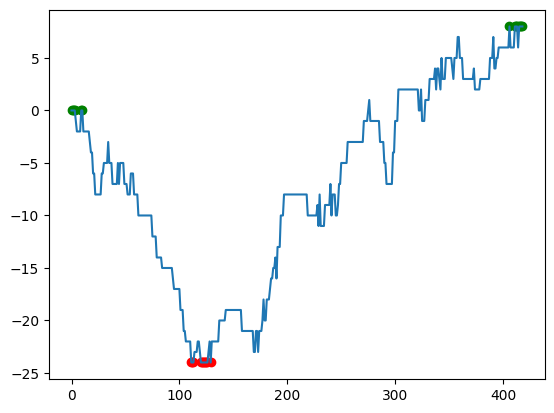

In [94]:
# Find local peaks
n=75
from scipy.signal import argrelextrema

test['min'] = test.iloc[argrelextrema(test.SCOREMARGIN.values, np.less_equal,
                    order=n)[0]]['SCOREMARGIN']
test['max'] = test.iloc[argrelextrema(test.SCOREMARGIN.values, np.greater_equal,
                    order=n)[0]]['SCOREMARGIN']

plt.scatter(test.index, test['min'], c='r')
plt.scatter(test.index, test['max'], c='g')
plt.plot(test.index, test['SCOREMARGIN'])
plt.show()

In [81]:

fig=px.line(test, 
        x="EVENTNUM", 
        y="SCOREMARGIN", 
        color='PHASE', 
        template="presentation",
        # symbol='MATCHUP', 
        title='<b>Game Trends</b>',
        hover_data=['PCTIMESTRING','SCORE', 'GAME_DATE', 'Season', 'Event_Type', 'HOMEDESCRIPTION', 'VISITORDESCRIPTION','PLAYER1_NAME','PLAYER2_NAME'], 
        height=750, width=1200,
        )

fig.update_layout(
    yaxis = dict(tickfont = dict(size=20)),
    xaxis = dict(tickfont = dict(size=20)),

    xaxis_title="<b>Event Number</b>",
    yaxis_title="<b>Score Margin</b>",

    font=dict(
        family="PT Sans Narrow",
        size=14,
        color="Black"
    ),

    title_x=0.5,

    hoverlabel=dict(
        bgcolor="white",
        font_size=16,
        font_family="PT Sans Narrow"
    ),
    )

fig.show()


In [80]:
for i in test.GAME_ID.unique():
    num=1
    for index,row in test.iterrows():
        if row.GAME_ID==i:
            if (row['PHASE DIFFERENTIAL HOME']==row['SCOREMARGIN']):
                test.loc[index,'MOMENTUM']=num
                num=num+1
test["MOMENTUM"] = test["MOMENTUM"].ffill()
test=test.fillna(0)
test["MOMENTUM"]=test["MOMENTUM"].astype(int)
test.head(5)

,GAME_ID,GAME_DATE,MATCHUP,EVENTNUM,PERIOD,PCTIMESTRING,Event,Event_Type,HOMEDESCRIPTION,NEUTRALDESCRIPTION,VISITORDESCRIPTION,SCORE,SCOREMARGIN,PLAYER1_NAME,PLAYER1_TEAM_ABBREVIATION,PLAYER2_NAME,PLAYER2_TEAM_ABBREVIATION,PLAYER3_NAME,PLAYER3_TEAM_ABBREVIATION,Season,RK,SCOREMARGIN_Diff,LEAD_LAG,CLUTCH,MARGIN,WAYPOINT,PHASE,PHASE DIFFERENTIAL HOME,PHASE DELTA HOME,PHASE DIFFERENTIAL ROAD,PHASE DELTA ROAD,ALL PHASES HOME,ALL PHASES ROAD,MOMENTUM
0,0029700672,1998-02-04,CHI @ UTA,1,1,12:00,Jump Ball,Jump ball,Jump Ball Ostertag vs. Longley: Tip to Jordan,No,No,0-0,0,Greg Ostertag,UTA,Luc Longley,CHI,Michael Jordan,CHI,1997-98,2.0,0.0,ALL,6-12 MIN,0,No Change,0,0,0.0,0,0.0,"[0, -2, 0, -24, 0, 1, -7, 2, 0, 2, -1, 8]","[0, 2, 0, 24, 0, -1, 7, -2, 0, -2, 1, -8]",1
1,0029700672,1998-02-04,CHI @ UTA,2,1,11:39,Missed FG,Jump Shot/3PT Jump Shot,No,No,MISS Longley 19' Jump Shot,0-0,0,Luc Longley,CHI,No,No,No,No,1997-98,3.0,0.0,ALL,6-12 MIN,0,No Change,0,0,0.0,0,0.0,"[0, -2, 0, -24, 0, 1, -7, 2, 0, 2, -1, 8]","[0, 2, 0, 24, 0, -1, 7, -2, 0, -2, 1, -8]",2
2,0029700672,1998-02-04,CHI @ UTA,3,1,11:36,Rebound,Rebound,No,No,Rodman REBOUND (Off:1 Def:0),0-0,0,Dennis Rodman,CHI,No,No,No,No,1997-98,4.0,0.0,ALL,6-12 MIN,0,No Change,0,0,0.0,0,0.0,"[0, -2, 0, -24, 0, 1, -7, 2, 0, 2, -1, 8]","[0, 2, 0, 24, 0, -1, 7, -2, 0, -2, 1, -8]",3
3,0029700672,1998-02-04,CHI @ UTA,4,1,11:27,Foul,S Foul,Ostertag S.FOUL (P1.T1),No,No,0-0,0,Greg Ostertag,UTA,No,No,No,No,1997-98,5.0,0.0,ALL,6-12 MIN,0,No Change,0,0,0.0,0,0.0,"[0, -2, 0, -24, 0, 1, -7, 2, 0, 2, -1, 8]","[0, 2, 0, 24, 0, -1, 7, -2, 0, -2, 1, -8]",4
4,0029700672,1998-02-04,CHI @ UTA,5,1,11:27,Free Throw Attempts,Free Throw 1 of 2,No,No,Longley Free Throw 1 of 2 (1 PTS),1 - 0,-1,Luc Longley,CHI,No,No,No,No,1997-98,6.0,1.0,HOME DEFICIT,6-12 MIN,<=5,Lead Switch,1,-2,-2.0,2,2.0,"[0, -2, 0, -24, 0, 1, -7, 2, 0, 2, -1, 8]","[0, 2, 0, 24, 0, -1, 7, -2, 0, -2, 1, -8]",4


In [59]:
# test[(test["GAME_ID"]=="0029700672")&(test["PHASE"]==3)].head(200)
test[(test["GAME_ID"]=="0029700672")].head(5)

,GAME_ID,GAME_DATE,MATCHUP,EVENTNUM,PERIOD,PCTIMESTRING,Event,Event_Type,HOMEDESCRIPTION,NEUTRALDESCRIPTION,VISITORDESCRIPTION,SCORE,SCOREMARGIN,PLAYER1_NAME,PLAYER1_TEAM_ABBREVIATION,PLAYER2_NAME,PLAYER2_TEAM_ABBREVIATION,PLAYER3_NAME,PLAYER3_TEAM_ABBREVIATION,Season,RK,SCOREMARGIN_Diff,LEAD_LAG,CLUTCH,MARGIN,WAYPOINT,PHASE,PHASE DIFFERENTIAL HOME,PHASE DELTA HOME,PHASE DIFFERENTIAL ROAD,PHASE DELTA ROAD,ALL PHASES HOME,ALL PHASES ROAD,MOMENTUM
0,0029700672,1998-02-04,CHI @ UTA,1,1,12:00,Jump Ball,Jump ball,Jump Ball Ostertag vs. Longley: Tip to Jordan,No,No,0-0,0,Greg Ostertag,UTA,Luc Longley,CHI,Michael Jordan,CHI,1997-98,2.0,0.0,ALL,6-12 MIN,0,No Change,0,0,0.0,0,0.0,"[0, -2, 0, -24, 0, 1, -7, 2, 0, 2, -1, 8]","[0, 2, 0, 24, 0, -1, 7, -2, 0, -2, 1, -8]",1
1,0029700672,1998-02-04,CHI @ UTA,2,1,11:39,Missed FG,Jump Shot/3PT Jump Shot,No,No,MISS Longley 19' Jump Shot,0-0,0,Luc Longley,CHI,No,No,No,No,1997-98,3.0,0.0,ALL,6-12 MIN,0,No Change,0,0,0.0,0,0.0,"[0, -2, 0, -24, 0, 1, -7, 2, 0, 2, -1, 8]","[0, 2, 0, 24, 0, -1, 7, -2, 0, -2, 1, -8]",2
2,0029700672,1998-02-04,CHI @ UTA,3,1,11:36,Rebound,Rebound,No,No,Rodman REBOUND (Off:1 Def:0),0-0,0,Dennis Rodman,CHI,No,No,No,No,1997-98,4.0,0.0,ALL,6-12 MIN,0,No Change,0,0,0.0,0,0.0,"[0, -2, 0, -24, 0, 1, -7, 2, 0, 2, -1, 8]","[0, 2, 0, 24, 0, -1, 7, -2, 0, -2, 1, -8]",3
3,0029700672,1998-02-04,CHI @ UTA,4,1,11:27,Foul,S Foul,Ostertag S.FOUL (P1.T1),No,No,0-0,0,Greg Ostertag,UTA,No,No,No,No,1997-98,5.0,0.0,ALL,6-12 MIN,0,No Change,0,0,0.0,0,0.0,"[0, -2, 0, -24, 0, 1, -7, 2, 0, 2, -1, 8]","[0, 2, 0, 24, 0, -1, 7, -2, 0, -2, 1, -8]",4
4,0029700672,1998-02-04,CHI @ UTA,5,1,11:27,Free Throw Attempts,Free Throw 1 of 2,No,No,Longley Free Throw 1 of 2 (1 PTS),1 - 0,-1,Luc Longley,CHI,No,No,No,No,1997-98,6.0,1.0,HOME DEFICIT,6-12 MIN,<=5,Lead Switch,1,-2,-2.0,2,2.0,"[0, -2, 0, -24, 0, 1, -7, 2, 0, 2, -1, 8]","[0, 2, 0, 24, 0, -1, 7, -2, 0, -2, 1, -8]",4


In [ ]:
#Get unique combinations of phase and phase margin variables
unique_combinations=test[['PHASE','PHASE DIFFERENTIAL HOME']].drop_duplicates()
unique_combinations=unique_combinations.reset_index(drop=True)

In [ ]:
fig_phase = px.area(
  unique_combinations, 
  x="PHASE", 
  y="PHASE DIFFERENTIAL HOME",
  # color="PLAYER_NAME_LAST_FIRST",
  template='plotly_white',
  title="<b>Game Phases</b>", 
  line_shape='spline',
  height=500, 
  width=900,
  )
fig_phase.update_layout(
    showlegend=False,
    title_x=0.5,
    hoverlabel=dict(
        bgcolor="white",
        font_size=16,
        font_family="PT Sans Narrow"
    ),
    yaxis = dict(tickfont = dict(size=15)),
    xaxis = dict(tickfont = dict(size=15)),
    font=dict(
        family="PT Sans Narrow",
        size=14,
        color="Black"
    ),
    title_font_family="PT Sans Narrow"
)
fig_phase

In [73]:
# #Create another column with the lag(1) vallue to compare
# test["SM2"]=test["SCOREMARGIN"].shift(1)
# test=test.fillna(0)
# test["SM2"]=test["SM2"].astype(int)

# #Create another column to track lead changes in the game
# for index,row in test.iterrows():
#   #multiply current and previous row.If the value is -ve, it means the sign has flipped and one of them is -ve. This is how we track a lead change
#   if row['SCOREMARGIN']*row['SM2']<0:
#     test.loc[index,'WAYPOINT'] = "Lead Switch"
#   elif (row['SCOREMARGIN']*row['SM2']==0) & ((row['SCOREMARGIN']!=0) | (row['SM2']!=0)):
#     test.loc[index,'WAYPOINT'] = "Lead Switch"  
#   else:
#     test.loc[index,'WAYPOINT'] = "No Change"  

# #Create a counter to track phases of the game
# num=1
# for index,row in test.iterrows():
#   if row['WAYPOINT']=='Lead Switch':
#     test.loc[index,'PHASE']=num
#     num=num+1
# test["PHASE"] = test["PHASE"].ffill()
# test=test.fillna(0)
# test["PHASE"]=test["PHASE"].astype(int)
# test=test.drop('SM2',axis=1)


# test["PREVIOUS PHASE DIFFERENTIAL"]=test["PHASE DIFFERENTIAL"].shift(1)
# for index,row in test.iterrows():
#   if row['RK']==2.0:
#     test.loc[index,'PREVIOUS PHASE DIFFERENTIAL'] =0

# for i in test['GAME_ID'].unique():
    # if test['GAME_ID']==i:
        # test["ALL PHASES ROAD"]=",".join(str(x) for x in test["PHASE DIFFERENTIAL ROAD"].unique())
# test.head(50)        

# test.assign(ALL_PHASES_HOME=test.groupby('GAME_ID')["PHASE DIFFERENTIAL HOME"].apply(lambda x: list(np.unique(x)))).head()

# all_df=pd.DataFrame(test.groupby(["GAME_ID"])[["PHASE DIFFERENTIAL HOME","PHASE DIFFERENTIAL ROAD"]].agg(['unique']))
# all_df=all_df.reset_index()
# all_df.columns=["GAME_ID","ALL PHASES HOME","ALL PHASES ROAD"]

# #Join this df with the original df
# test=test.merge(all_df, how='left', left_on="GAME_ID", right_on="GAME_ID")
# test.head()
